In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading and Initial Inspection

In [2]:
df = pd.read_csv("Superstore_data.csv",encoding="windows-1252")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.shape

(9994, 21)

In [4]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [5]:
df.drop(columns=["Row ID"],inplace=True)

In [6]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-","_")
)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       9994 non-null   str    
 1   Order_Date     9994 non-null   str    
 2   Ship_Date      9994 non-null   str    
 3   Ship_Mode      9994 non-null   str    
 4   Customer_ID    9994 non-null   str    
 5   Customer_Name  9994 non-null   str    
 6   Segment        9994 non-null   str    
 7   Country        9994 non-null   str    
 8   City           9994 non-null   str    
 9   State          9994 non-null   str    
 10  Postal_Code    9994 non-null   int64  
 11  Region         9994 non-null   str    
 12  Product_ID     9994 non-null   str    
 13  Category       9994 non-null   str    
 14  Sub_Category   9994 non-null   str    
 15  Product_Name   9994 non-null   str    
 16  Sales          9994 non-null   float64
 17  Quantity       9994 non-null   int64  
 18  Discount       9994

In [8]:
df.isnull().sum()

Order_ID         0
Order_Date       0
Ship_Date        0
Ship_Mode        0
Customer_ID      0
Customer_Name    0
Segment          0
Country          0
City             0
State            0
Postal_Code      0
Region           0
Product_ID       0
Category         0
Sub_Category     0
Product_Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(1)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.shape

(9993, 20)

### Standardize Text Columns

##### Finding string columns

In [12]:
str_cols=df.select_dtypes(include=["str"]).columns
str_cols

Index(['Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID',
       'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Region',
       'Product_ID', 'Category', 'Sub_Category', 'Product_Name'],
      dtype='str')

In [14]:
cols1=['Order_ID', 'Order_Date', 'Ship_Date' , 'Customer_ID','Product_ID',]


for col in cols1:
    df[col] = df[col].str.strip()

In [15]:
cols=['Ship Mode','Customer_Name', 'Segment', 'Country', 'City', 'State', 'Region', 'Category', 'Sub_Category', 'Product_Name']

for col in cols1:
    df[col] = df[col].str.strip().str.title()

In [16]:
df.head()

,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
0,Ca-2016-152156,11/8/2016,11/11/2016,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,Fur-Bo-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,Ca-2016-152156,11/8/2016,11/11/2016,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,Fur-Ch-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,Ca-2016-138688,6/12/2016,6/16/2016,Second Class,Dv-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,Off-La-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,Us-2015-108966,10/11/2015,10/18/2015,Standard Class,So-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,Fur-Ta-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,Us-2015-108966,10/11/2015,10/18/2015,Standard Class,So-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,Off-St-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [18]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
df["Ship_Date"] = pd.to_datetime(df["Ship_Date"], errors="coerce")

In [19]:
df.head(3)

,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
0,Ca-2016-152156,2016-11-08,2016-11-11,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,Fur-Bo-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,Ca-2016-152156,2016-11-08,2016-11-11,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,Fur-Ch-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,Ca-2016-138688,2016-06-12,2016-06-16,Second Class,Dv-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,Off-La-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [20]:
df.info()#Now all dtypes are correct

<class 'pandas.DataFrame'>
Index: 9993 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       9993 non-null   str           
 1   Order_Date     9993 non-null   datetime64[us]
 2   Ship_Date      9993 non-null   datetime64[us]
 3   Ship_Mode      9993 non-null   str           
 4   Customer_ID    9993 non-null   str           
 5   Customer_Name  9993 non-null   str           
 6   Segment        9993 non-null   str           
 7   Country        9993 non-null   str           
 8   City           9993 non-null   str           
 9   State          9993 non-null   str           
 10  Postal_Code    9993 non-null   int64         
 11  Region         9993 non-null   str           
 12  Product_ID     9993 non-null   str           
 13  Category       9993 non-null   str           
 14  Sub_Category   9993 non-null   str           
 15  Product_Name   9993 non-null   str   

In [21]:
df["Category"].value_counts()

Category
Office Supplies    6026
Furniture          2120
Technology         1847
Name: count, dtype: int64

In [22]:
df["Segment"].value_counts()

Segment
Consumer       5191
Corporate      3020
Home Office    1782
Name: count, dtype: int64

In [25]:
df["Region"].value_counts()

Region
West       3203
East       2847
Central    2323
South      1620
Name: count, dtype: int64

In [23]:
df["Country"].value_counts()

Country
United States    9993
Name: count, dtype: int64

In [24]:
df["State"].value_counts()

State
California              2001
New York                1128
Texas                    985
Pennsylvania             587
Washington               506
Illinois                 492
Ohio                     468
Florida                  383
Michigan                 255
North Carolina           249
Arizona                  224
Virginia                 224
Georgia                  184
Tennessee                183
Colorado                 182
Indiana                  149
Kentucky                 139
Massachusetts            135
New Jersey               130
Oregon                   124
Wisconsin                110
Maryland                 105
Delaware                  96
Minnesota                 89
Connecticut               82
Missouri                  66
Oklahoma                  66
Alabama                   61
Arkansas                  60
Rhode Island              56
Utah                      53
Mississippi               53
South Carolina            42
Louisiana                 42
Nevada  

In [26]:
df.describe()

,Order_Date,Ship_Date,Postal_Code,Sales,Quantity,Discount,Profit
count,9993,9993,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000
mean,2016-04-30 01:53:33.089162,2016-05-04 00:53:19.039327,55191.576403,229.852846,3.789753,0.156188,28.660971
min,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.731000
50%,2016-06-26 00:00:00,2016-06-29 00:00:00,56560.000000,54.480000,3.000000,0.200000,8.671000
75%,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,NaN,NaN,32065.074478,623.276074,2.225149,0.206457,234.271476


#### Filtering

In [32]:
Florida_customers = df[df["State"] == "Florida"]
Florida_customers.head(3)

,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
3,Us-2015-108966,2015-10-11,2015-10-18,Standard Class,So-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,Fur-Ta-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,Us-2015-108966,2015-10-11,2015-10-18,Standard Class,So-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,Off-St-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
43,Ca-2017-139619,2017-09-19,2017-09-23,Standard Class,Es-14080,Erin Smith,Corporate,United States,Melbourne,Florida,32935,South,Off-St-10003282,Office Supplies,Storage,"Advantus 10-Drawer Portable Organizer, Chrome ...",95.6160,2,0.20,9.5616


### Sorting

In [34]:
top_sales_records = df.sort_values(by="Profit", ascending=False)
top_sales_records.head()

,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
6826,Ca-2016-118689,2016-10-02,2016-10-09,Standard Class,Tc-20980,Tamara Chand,Corporate,United States,Lafayette,Indiana,47905,Central,Tec-Co-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,17499.95,5,0.0,8399.9760
8153,Ca-2017-140151,2017-03-23,2017-03-25,First Class,Rb-19360,Raymond Buch,Consumer,United States,Seattle,Washington,98115,West,Tec-Co-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,13999.96,4,0.0,6719.9808
4190,Ca-2017-166709,2017-11-17,2017-11-22,Standard Class,Hl-15040,Hunter Lopez,Consumer,United States,Newark,Delaware,19711,East,Tec-Co-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,10499.97,3,0.0,5039.9856
9039,Ca-2016-117121,2016-12-17,2016-12-21,Standard Class,Ab-10105,Adrian Barton,Consumer,United States,Detroit,Michigan,48205,Central,Off-Bi-10000545,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,9892.74,13,0.0,4946.3700
4098,Ca-2014-116904,2014-09-23,2014-09-28,Standard Class,Sc-20095,Sanjit Chand,Consumer,United States,Minneapolis,Minnesota,55407,Central,Off-Bi-10001120,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,9449.95,5,0.0,4630.4755


In [35]:
recent_sales = df.sort_values(by="Order_Date", ascending=False).head(10)
recent_sales

,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
906,Ca-2017-143259,2017-12-30,2018-01-03,Standard Class,Po-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,10009,East,Fur-Bo-10003441,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Fully Ass...",323.136,4,0.2,12.1176
907,Ca-2017-143259,2017-12-30,2018-01-03,Standard Class,Po-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,10009,East,Tec-Ph-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.0,2.7279
1296,Ca-2017-115427,2017-12-30,2018-01-03,Standard Class,Eb-13975,Erica Bern,Corporate,United States,Fairfield,California,94533,West,Off-Bi-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",13.904,2,0.2,4.5188
1297,Ca-2017-115427,2017-12-30,2018-01-03,Standard Class,Eb-13975,Erica Bern,Corporate,United States,Fairfield,California,94533,West,Off-Bi-10004632,Office Supplies,Binders,GBC Binding covers,20.720,2,0.2,6.4750
645,Ca-2017-126221,2017-12-30,2018-01-05,Standard Class,Cc-12430,Chuck Clark,Home Office,United States,Columbus,Indiana,47201,Central,Off-Ap-10002457,Office Supplies,Appliances,Eureka The Boss Plus 12-Amp Hard Box Upright V...,209.300,2,0.0,56.5110
908,Ca-2017-143259,2017-12-30,2018-01-03,Standard Class,Po-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,10009,East,Off-Bi-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,3,0.2,19.7910
5091,Ca-2017-156720,2017-12-30,2018-01-03,Standard Class,Jm-15580,Jill Matthias,Consumer,United States,Loveland,Colorado,80538,West,Off-Fa-10003472,Office Supplies,Fasteners,Bagged Rubber Bands,3.024,3,0.2,-0.6048
7634,Us-2017-158526,2017-12-29,2018-01-01,Second Class,Kh-16360,Katherine Hughes,Consumer,United States,Louisville,Kentucky,40214,South,Off-Ar-10003696,Office Supplies,Art,Panasonic KP-350BK Electric Pencil Sharpener w...,34.580,1,0.0,10.0282
4239,Ca-2017-158673,2017-12-29,2018-01-04,Standard Class,Kb-16600,Ken Brennan,Corporate,United States,Grand Rapids,Michigan,49505,Central,Off-Pa-10000994,Office Supplies,Paper,Xerox 1915,209.700,2,0.0,100.6560
1877,Ca-2017-118885,2017-12-29,2018-01-02,Standard Class,Jg-15160,James Galang,Consumer,United States,Los Angeles,California,90049,West,Fur-Ch-10002880,Furniture,Chairs,"Global High-Back Leather Tilter, Burgundy",393.568,4,0.2,-44.2764


In [36]:
df.to_csv("Cleaned_sales.csv",index=False)

print("Cleaned_dataset_saved")

Cleaned_dataset_saved


# Grouping

#### Single-Level Grouping

In [57]:
category_summary = df.groupby("Category").agg(
    record_count=("Category", "count"),
    total_amount=("Sales", "sum"),
    average_amount=("Sales", "mean"),
    minimum_amount=("Sales", "min"),
    maximum_amount=("Sales", "max")
).reset_index()

category_summary

,Category,record_count,total_amount,average_amount,minimum_amount,maximum_amount
0,Furniture,2120,741718.4233,349.867181,1.892,4416.174
1,Office Supplies,6026,719047.0320,119.324101,0.444,9892.740
2,Technology,1847,836154.0330,452.709276,0.990,22638.480


#### Multi-Level Grouping

In [59]:
region_category_summary = df.groupby(["Region", "Category"]).agg(
    record_count=("Sales", "count"),
    total_amount=("Sales", "sum"),
    average_amount=("Sales", "mean")
).reset_index()

region_category_summary

,Region,Category,record_count,total_amount,average_amount
0,Central,Furniture,481,163797.1638,340.534644
1,Central,Office Supplies,1422,167026.4150,117.458801
2,Central,Technology,420,170416.3120,405.753124
3,East,Furniture,600,208009.8320,346.683053
4,East,Office Supplies,1712,205516.0550,120.044425
5,East,Technology,535,264973.9810,495.278469
6,South,Furniture,332,117298.6840,353.309289
7,South,Office Supplies,995,125651.3130,126.282727
8,South,Technology,293,148771.9080,507.753952
9,West,Furniture,707,252612.7435,357.302325


#### Grouping by Sub_Category to get a meaningful Top 10 list

In [61]:
# Grouping by Sub_Category to get a meaningful Top 10 list
sub_category_summary = df.groupby("Sub_Category").agg(
    record_count=("Sub_Category", "count"),
    total_amount=("Sales", "sum"),
    average_amount=("Sales", "mean"),
    minimum_amount=("Sales", "min"),
    maximum_amount=("Sales", "max")
).reset_index()

top_10_groups = sub_category_summary.sort_values(
    by="total_amount",
    ascending=False
).head(10)

top_10_groups

,Sub_Category,record_count,total_amount,average_amount,minimum_amount,maximum_amount
13,Phones,889,330007.0540,371.211534,2.970,4548.810
5,Chairs,616,328167.7310,532.739823,26.640,4416.174
14,Storage,846,223843.6080,264.590553,4.464,2934.330
16,Tables,319,206965.5320,648.794771,24.368,4297.644
3,Binders,1523,203412.7330,133.560560,0.556,9892.740
11,Machines,115,189238.6310,1645.553313,11.560,22638.480
0,Accessories,775,167380.3180,215.974604,0.990,3347.370
6,Copiers,68,149528.0300,2198.941618,299.990,17499.950
4,Bookcases,228,114879.9963,503.859633,35.490,4404.900
1,Appliances,466,107532.1610,230.755710,0.444,2625.120


# Visualization

##### Total Sales by Category

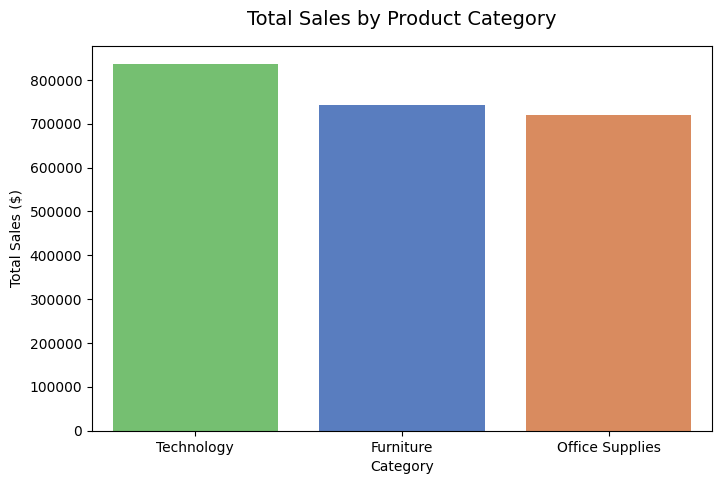

In [49]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Category', y='Sales', hue="Category", estimator=sum, errorbar=None, 
            order=['Technology', 'Furniture', 'Office Supplies'], palette='muted')
plt.title('Total Sales by Product Category', fontsize=14, pad=15)
plt.ylabel('Total Sales ($)')
plt.xlabel('Category')
plt.show()

#### Sales vs. Profit

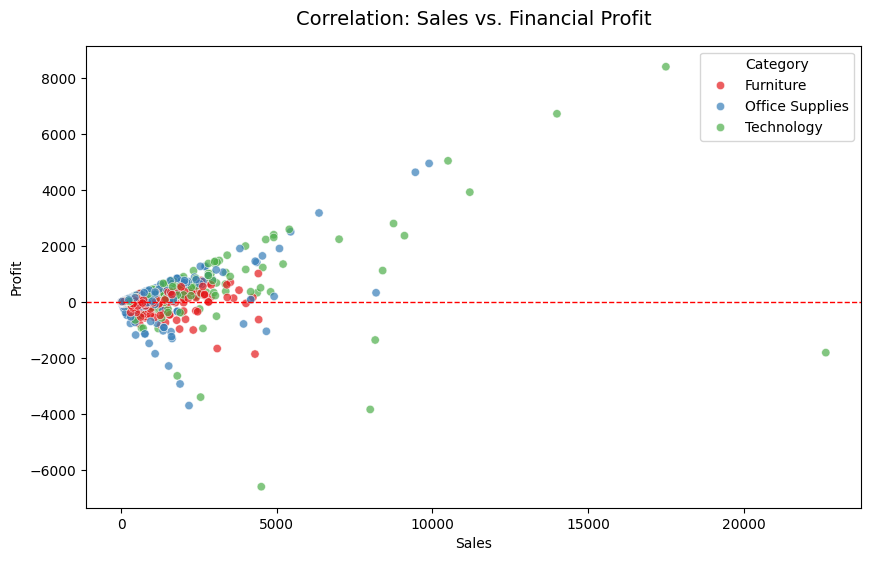

In [50]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category', alpha=0.7, palette='Set1')
plt.title('Correlation: Sales vs. Financial Profit', fontsize=14, pad=15)
plt.axhline(0, color='red', linestyle='--', linewidth=1) # Adds a baseline for loss vs profit
plt.show()

#### Order Count by Customer Segment

<Axes: xlabel='Segment', ylabel='count'>

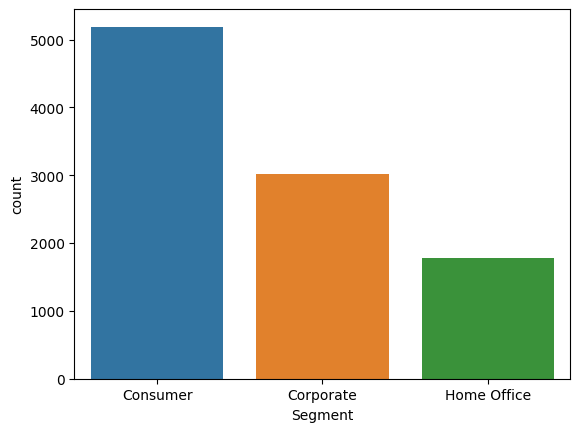

In [44]:
sns.countplot(data=df, x='Segment',hue="Segment", order=df['Segment'].value_counts().index)

##### Distribution of Order Quantities

<Axes: xlabel='Quantity', ylabel='Count'>

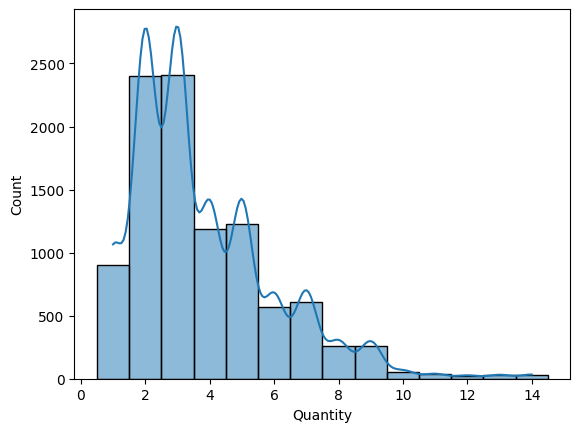

In [46]:
sns.histplot(data=df, x='Quantity',kde=True,discrete=True)

#### Sales over time trend

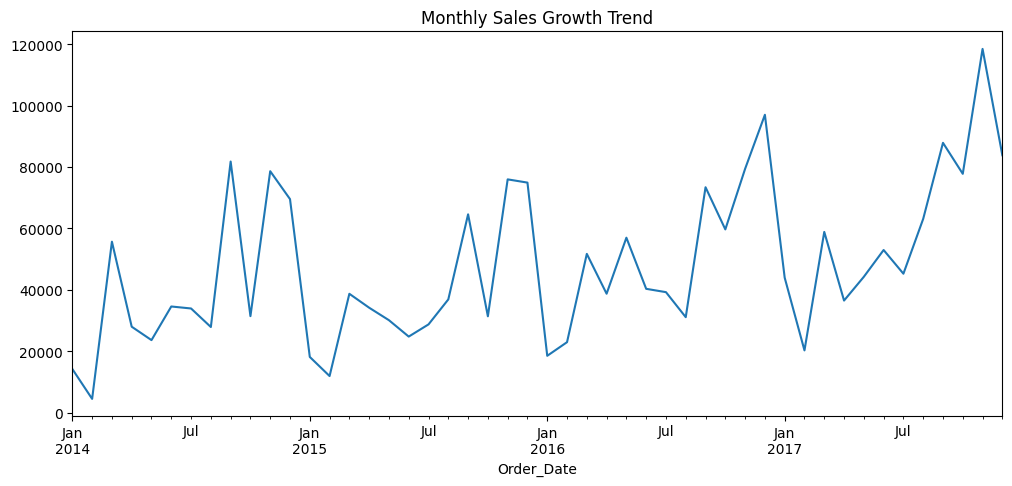

In [53]:

df.set_index('Order_Date').resample('ME')['Sales'].sum().plot(kind='line', figsize=(12, 5))
plt.title('Monthly Sales Growth Trend')
plt.show()

#### Regional profitability matrices

In [55]:
df.pivot_table(index='Region', columns='Category', values='Profit', aggfunc='sum')

Category,Furniture,Office Supplies,Technology
Region,,,
Central,-2871.0494,8879.9799,33697.4320
East,3058.2246,41014.5791,47462.0351
South,6771.2061,19986.3928,19991.8314
West,11504.9503,52609.8490,44303.6496
